# Iris Dataset - Exploratory Data Analysis & Feature Engineering Task

This notebook demonstrates end-to-end Exploratory Data Analysis (EDA), feature vs. target separation, visualization, and train-test splitting using `scikit-learn` on the classic Iris Flower Dataset (`Iris.csv`).

### 1. Import Data Science Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

### 2. Load Dataset (`Iris.csv`)

In [2]:
# Load Iris CSV file into Pandas DataFrame
data = pd.read_csv("Iris.csv")
df = pd.DataFrame(data)
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### 3. Data Understanding & Structural Audit

#### 3.1 Display First 5 Rows (`df.head()`)

In [3]:
# Preview the first 5 records
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


#### 3.2 Display Last 5 Rows (`df.tail()`)

In [4]:
# Preview the last 5 records
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


#### 3.3 Random Sample (`df.sample(5)`)

In [5]:
# Random sample of 5 rows
df.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
18,19,5.7,3.8,1.7,0.3,Iris-setosa
137,138,6.4,3.1,5.5,1.8,Iris-virginica
86,87,6.7,3.1,4.7,1.5,Iris-versicolor
43,44,5.0,3.5,1.6,0.6,Iris-setosa
105,106,7.6,3.0,6.6,2.1,Iris-virginica


#### 3.4 Dataset Dimensions & Total Size

In [6]:
print('Shape (rows, cols):', df.shape)
print('Total Size (elements):', df.size)

Shape (rows, cols): (150, 6)
Total Size (elements): 900


#### 3.5 Column Headers & Data Types

In [7]:
print('Column Names:', list(df.columns))
print('\nData Types:\n', df.dtypes)

Column Names: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Data Types:
 Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object


#### 3.6 Dataset Info & Memory Summary (`df.info()`)

In [8]:
# Summary of non-null counts, data types, and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


#### 3.7 Statistical Summary (`df.describe()`)

In [9]:
# Summary statistics for numerical feature measurements
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


#### 3.8 Check Missing Values & Duplicates

In [10]:
print('Missing Values per Column:\n', df.isnull().sum())
print('\nDuplicate Rows Count:', df.duplicated().sum())

Missing Values per Column:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Duplicate Rows Count: 0


#### 3.9 Target Class Distribution (`df['Species'].value_counts()`)

In [11]:
# Frequency count of target species classes
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

### 4. Data Preprocessing & Feature Cleaning

#### 4.1 Drop Unnecessary Identifier Column (`Id`)

In [12]:
# Remove 'Id' column as it doesn't contribute predictive value
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


#### 4.2 Groupby Target Species Means

In [13]:
# Compare mean measurement values for each species
df.groupby('Species').mean()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


### 5. Exploratory Data Visualization

#### 5.1 Target Class Distribution Bar Chart

C:\Users\arjun\AppData\Local\Temp\ipykernel_10180\2794451047.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=species_counts.index, y=species_counts.values, palette='viridis')


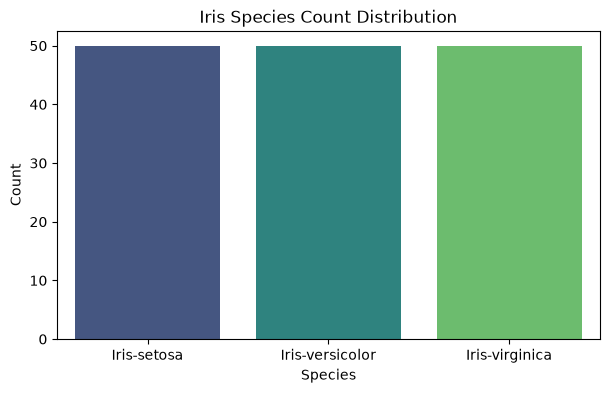

In [14]:
species_counts = df['Species'].value_counts()
plt.figure(figsize=(7, 4))
sns.barplot(x=species_counts.index, y=species_counts.values, palette='viridis')
plt.title('Iris Species Count Distribution')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

#### 5.2 Feature Distribution Histograms

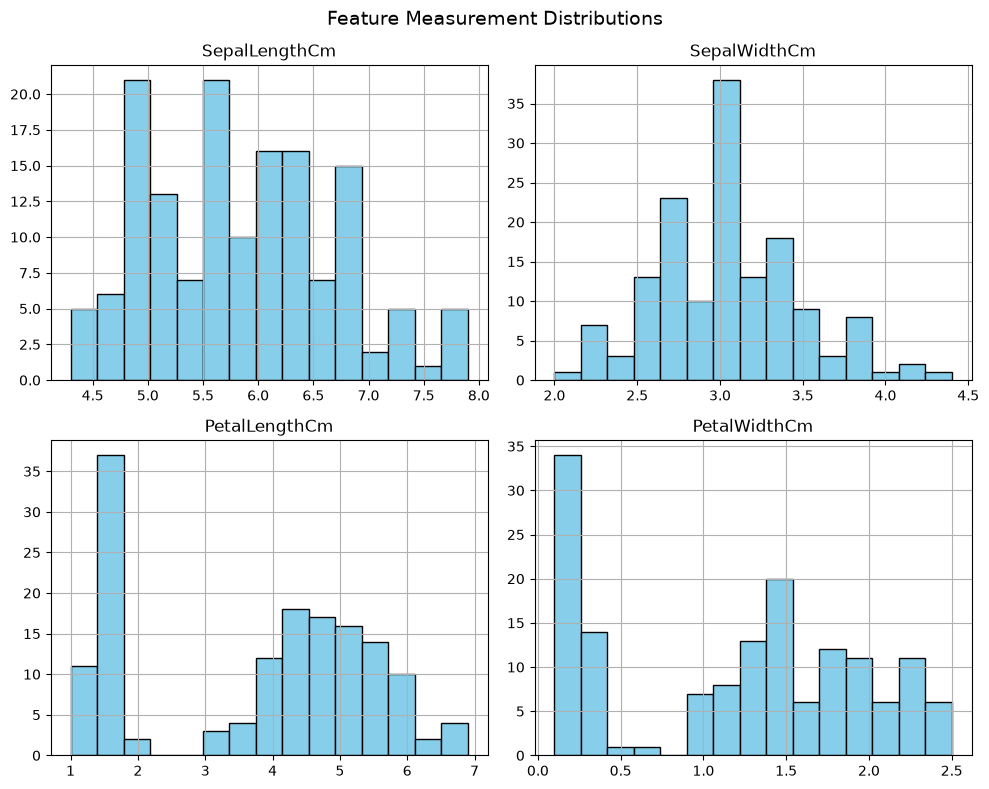

In [15]:
df.hist(figsize=(10, 8), color='skyblue', edgecolor='black', bins=15)
plt.suptitle('Feature Measurement Distributions', fontsize=14)
plt.tight_layout()
plt.show()

#### 5.3 Scatter Plot: Sepal Length vs. Sepal Width

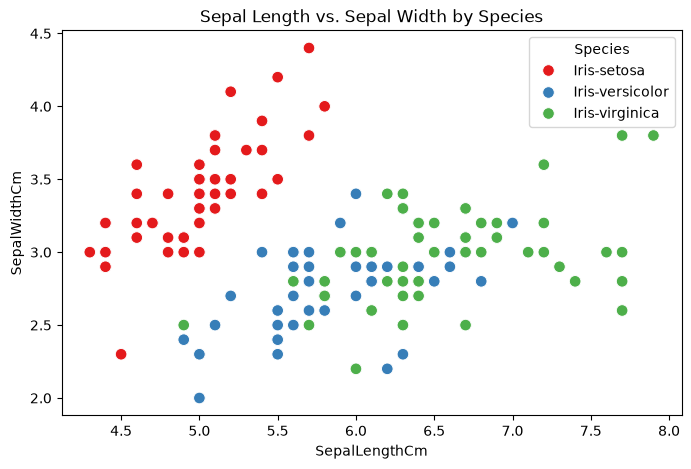

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='SepalLengthCm', y='SepalWidthCm', hue='Species', palette='Set1', s=70)
plt.title('Sepal Length vs. Sepal Width by Species')
plt.show()

#### 5.4 Scatter Plot: Petal Length vs. Petal Width

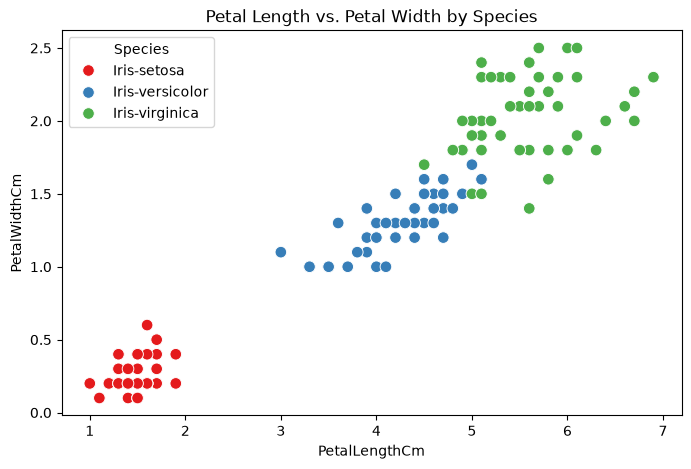

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='PetalLengthCm', y='PetalWidthCm', hue='Species', palette='Set1', s=70)
plt.title('Petal Length vs. Petal Width by Species')
plt.show()

#### 5.5 Correlation Heatmap of Numerical Features

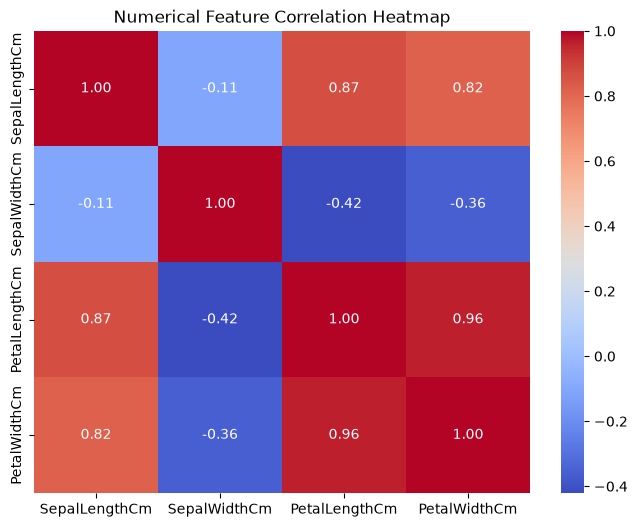

In [18]:
plt.figure(figsize=(8, 6))
numeric_df = df.drop('Species', axis=1)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

### 6. Feature Matrix (X) and Target Vector (y) Separation

#### 6.1 Separate Features (X) and Target (y)

In [19]:
# Input features matrix X (independent variables)
X = df.drop("Species", axis=1)

# Target vector y (dependent variable)
y = df["Species"]

print("Feature Matrix X Shape:", X.shape)
print("Target Vector y Shape:", y.shape)
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 values of y:")
display(y.head())

Feature Matrix X Shape: (150, 4)
Target Vector y Shape: (150,)

First 5 rows of X:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



First 5 values of y:


0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: str

#### 6.2 Encode Categorical Target Labels

In [20]:
# Encode target species names to numeric values (0, 1, 2)
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Class Mapping:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))
print("First 10 Encoded Target Values:", y_encoded[:10])

Class Mapping: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}
First 10 Encoded Target Values: [0 0 0 0 0 0 0 0 0 0]


### 7. Train-Test Splitting & Feature Scaling (Scikit-Learn)

#### 7.1 Train-Test Split (80% Train, 20% Test)

In [21]:
# Split dataset into training set (80%) and test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training Feature Set Shape (X_train):", X_train.shape)
print("Testing Feature Set Shape (X_test):", X_test.shape)
print("Training Target Shape (y_train):", y_train.shape)
print("Testing Target Shape (y_test):", y_test.shape)

Training Feature Set Shape (X_train): (120, 4)
Testing Feature Set Shape (X_test): (30, 4)
Training Target Shape (y_train): (120,)
Testing Target Shape (y_test): (30,)


#### 7.2 Feature Scaling using StandardScaler

In [22]:
# Standardize features by removing mean and scaling to unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 3 Scaled Training Samples:")
print(X_train_scaled[:3])

First 3 Scaled Training Samples:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]]
